In [ ]:
import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})

### Day 4

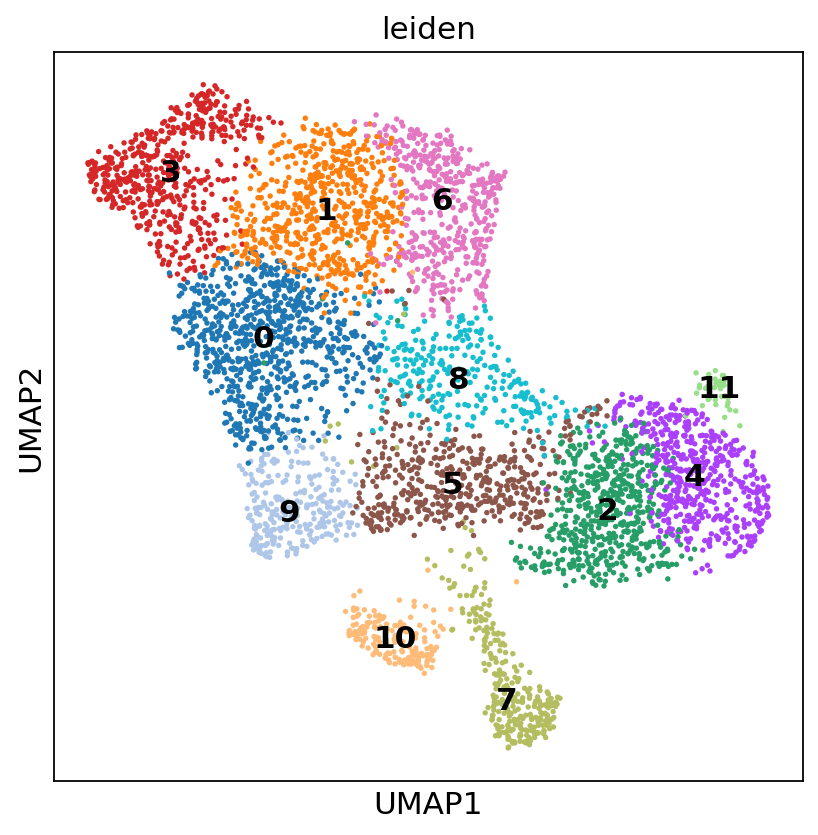

In [8]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

In [5]:
adata = adata[adata.obs['CellType_man'] == 'Endo'].copy()

In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)


In [11]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


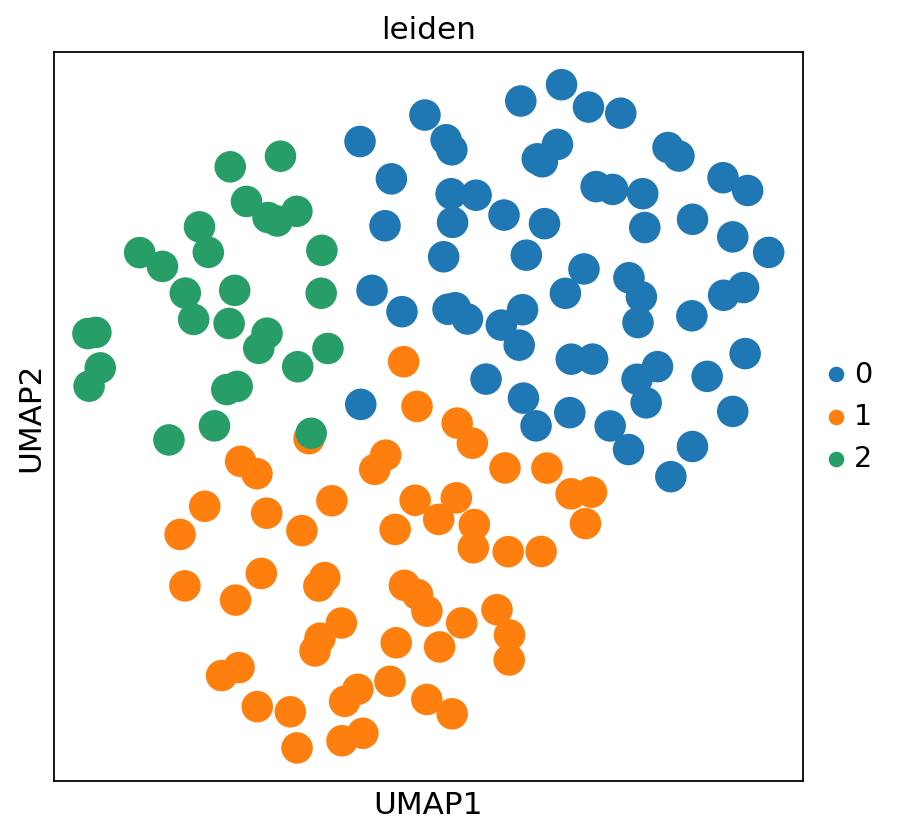

In [12]:
sc.pl.umap(adata, color=['leiden'])

In [17]:
cluster_annotations = {
    '0': 'CDX2+ Hypo',
    '1': 'Late Hypo',
    '2': 'Early Hypo'}

adata.obs['subcluster_man'] = adata.obs['leiden'].map(cluster_annotations)
adata.write('./2512-revision/hemo4_endo.h5ad')

In [22]:
sc.pl.dotplot(
    adata,
    # {'Hypo': ['POU5F1', 'SOX17', 'GATA4', 'GATA6', 'PDGFRA'],
    #  'YS.Mes': ['AFP', 'APOA1'],
    #  # 'ExMC': ['CDX2', 'HAND1', 'GATA3', 'GATA2', 'TEAD4', 'VIM'],
    #  'Ery': ['HBZ', 'HBE1', 'GYPA', 'GYPB']},
    ['POU5F1', 'SOX17', 'FOXA2', 'CXCR4', 
     'GATA4', 'GATA6', 'PDGFRA', 
     'AFP', 'APOA1', 'CDX2', 'HAND1', 
     'HBZ', 'HBE1', 'GYPA', 'GYPB'],
    groupby='subcluster_man',
    dendrogram=False,  
    cmap='Reds',
    # var_group_rotation=90,
    standard_scale='var',
    swap_axes=True,
    figsize=(3, 5), 
    # title='HCBE Endoderm subtypes marker gene expression',
    show=False
)
plt.savefig(f'/mnt/yiming/nfs_share/hema_wave/2512-revision/3_hemo4_dotplot_endo_geneexp.svg', 
                format='svg', dpi=300, bbox_inches='tight')
plt.close()

In [24]:
sc.pl.umap(adata, color=['subcluster_man'], 
           legend_loc='on data', legend_fontsize=15, legend_fontoutline=2, 
           title='HCEB D4 Endo Subtype',
          frameon=False, show=False)
plt.savefig(f'/mnt/yiming/nfs_share/hema_wave/2512-revision/3_hemo4_umap_endo_subtype_legendon.svg', 
                format='svg', dpi=300, bbox_inches='tight')
plt.close()

In [26]:
adata_full = sc.read_h5ad("hemo-larry-d4-rna-clone-v2.h5ad")
adata_endo = sc.read_h5ad("./2512-revision/hemo4_endo.h5ad")
adata_full.obs["CellType_man_v2"] = adata_full.obs["CellType_man"].astype(str)
adata_full.obs.loc[
    adata_endo.obs_names,
    "CellType_man_v2"
] = adata_endo.obs["subcluster_man"].astype(str).values

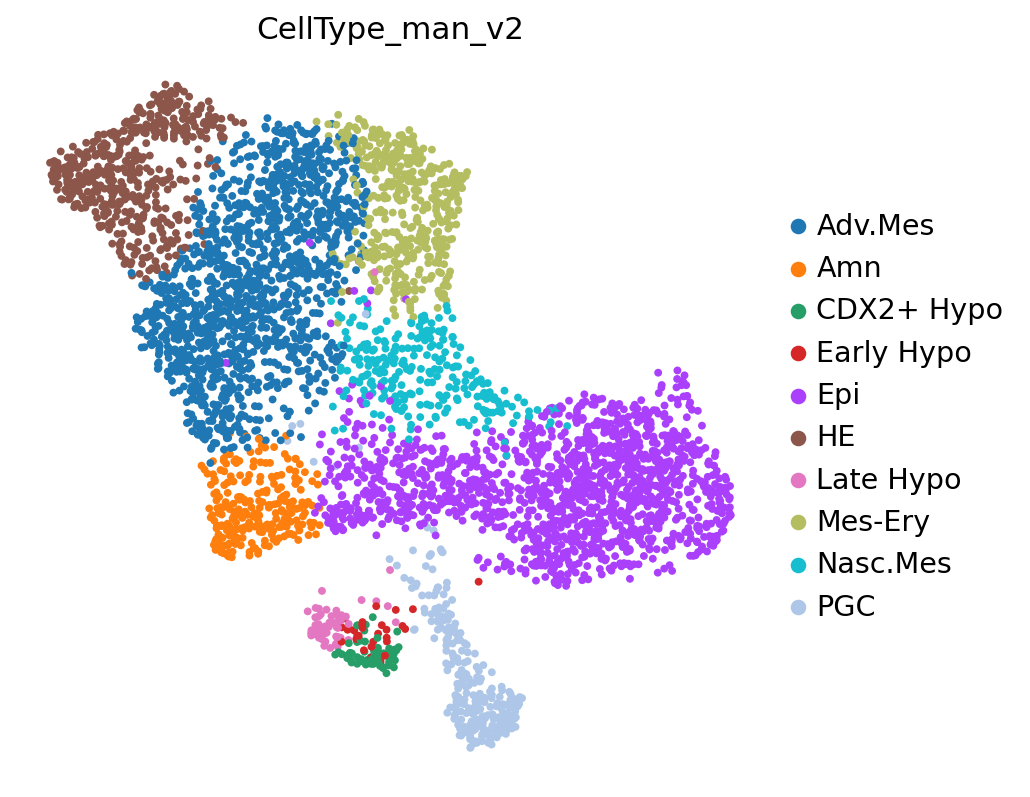

In [30]:
sc.pl.umap(adata_full, color=['CellType_man_v2'], 
           size=50, 
           frameon=False, show=False)
plt.savefig(f'/mnt/yiming/nfs_share/hema_wave/2512-revision/3_hemo4_umap_with_endo_sub.svg', 
                format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Day 7

In [3]:
import celltypist
from celltypist import models
import scipy

adata = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d7-rna.h5ad')
adata.X = adata.layers['counts']
if scipy.sparse.issparse(adata.X):
    adata.X = adata.X.toarray()
# adata.X[np.isnan(adata.X)] = 0
sc.pp.normalize_total(adata, target_sum = 1e4) 
sc.pp.log1p(adata)

hembryo_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/hembryo_model.pkl")
predictions = celltypist.annotate(adata, model=hembryo_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["hembryo_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["hembryo_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

Tyser_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model.pkl")
predictions = celltypist.annotate(adata, model=Tyser_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

Tyser_model_v2 = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model_v2.pkl")
predictions = celltypist.annotate(adata, model=Tyser_model_v2, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label_v2"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score_v2"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

normalizing counts per cell
    finished (0:00:00)


🔬 Input data has 4621 cells and 29701 genes
🔗 Matching reference genes in the model
🧬 6530 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished: found 63 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:01)


🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 4621 cells and 29701 genes
🔗 Matching reference genes in the model
🧬 3082 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished: found 63 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:01)


🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 4621 cells and 29701 genes
🔗 Matching reference genes in the model
🧬 2325 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished: found 63 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:01)


🗳️ Majority voting the predictions
✅ Majority voting done!


In [4]:
from collections import Counter

# Get Leiden clusters and cell type labels
leiden_clusters = adata.obs['leiden'].astype(str)
cell_types = adata.obs['Tyser_label']

# Create a DataFrame for easier manipulation
df = pd.DataFrame({
    'leiden': leiden_clusters,
    'Tyser_label': cell_types
})

summary_df = pd.crosstab(df['leiden'], df['Tyser_label'], normalize='index') * 100
dominant_types = summary_df.idxmax(axis=1)
dominant_percentages = summary_df.max(axis=1)
dominant_df = pd.DataFrame({
    'Leiden_cluster': dominant_types.index,
    'Dominant_cell_type': dominant_types.values,
    'Percentage': dominant_percentages.values
})
print("\n\nDominant cell types for each Leiden cluster:")
print(dominant_df)

adata.obs['leiden_annotation_v1'] = adata.obs['leiden'].astype(str)  # Start with leiden labels
for leiden_cluster in dominant_types.index:
    mask = adata.obs['leiden'] == leiden_cluster
    adata.obs.loc[mask, 'leiden_annotation_v1'] = dominant_types[leiden_cluster]

print("Annotation mapping:")
for leiden_cluster, cell_type in dominant_types.items():
    print(f"Leiden {leiden_cluster} → {cell_type}")



Dominant cell types for each Leiden cluster:
   Leiden_cluster     Dominant_cell_type  Percentage
0               0      Advanced Mesoderm   48.757170
1               1                 Amnion   90.338164
2              10      Advanced Mesoderm   92.708333
3              11      Advanced Mesoderm   69.849246
4              12  Hemogenic Endothelium   56.521739
5              13                    PGC   74.358974
6              14              Hypoblast   38.000000
7              15      Emergent Mesoderm   36.363636
8               2  Hemogenic Endothelium   99.764706
9               3       Primitive Streak   55.246914
10              4                 Amnion   61.035422
11              5      Advanced Mesoderm   89.402174
12              6      Advanced Mesoderm   62.770563
13              7               Epiblast   75.675676
14              8      Blood Progenitors   60.937500
15              9      Advanced Mesoderm   97.347480
Annotation mapping:
Leiden 0 → Advanced Mesoderm
Lei

In [5]:
def simple_leiden_annotation(adata, celltype_col):
    """
    Simple function for Leiden annotation.
    """
    import pandas as pd
    
    # Create DataFrame
    df = pd.DataFrame({
        'leiden': adata.obs['leiden'].astype(str),
        'cell_type': adata.obs[celltype_col]
    })
    
    # Calculate dominant types
    summary = pd.crosstab(df['leiden'], df['cell_type'], normalize='index') * 100
    dominant = summary.idxmax(axis=1)
    percentages = summary.max(axis=1)
    
    # Create annotation column
    new_col = f'leiden_annotation_{celltype_col}'
    adata.obs[new_col] = adata.obs['leiden'].astype(str)
    
    for cluster in dominant.index:
        mask = adata.obs['leiden'] == cluster
        adata.obs.loc[mask, new_col] = dominant[cluster]
    
    # Create summary DataFrame
    result_df = pd.DataFrame({
        'Leiden_cluster': dominant.index,
        'Dominant_cell_type': dominant.values,
        'Percentage': percentages.values
    })
    
    return result_df, adata


# Usage
dominant_v1, adata = simple_leiden_annotation(adata, 'Tyser_label')
dominant_v2, adata = simple_leiden_annotation(adata, 'Tyser_label_v2')
dominant_v3, adata = simple_leiden_annotation(adata, 'hembryo_label')

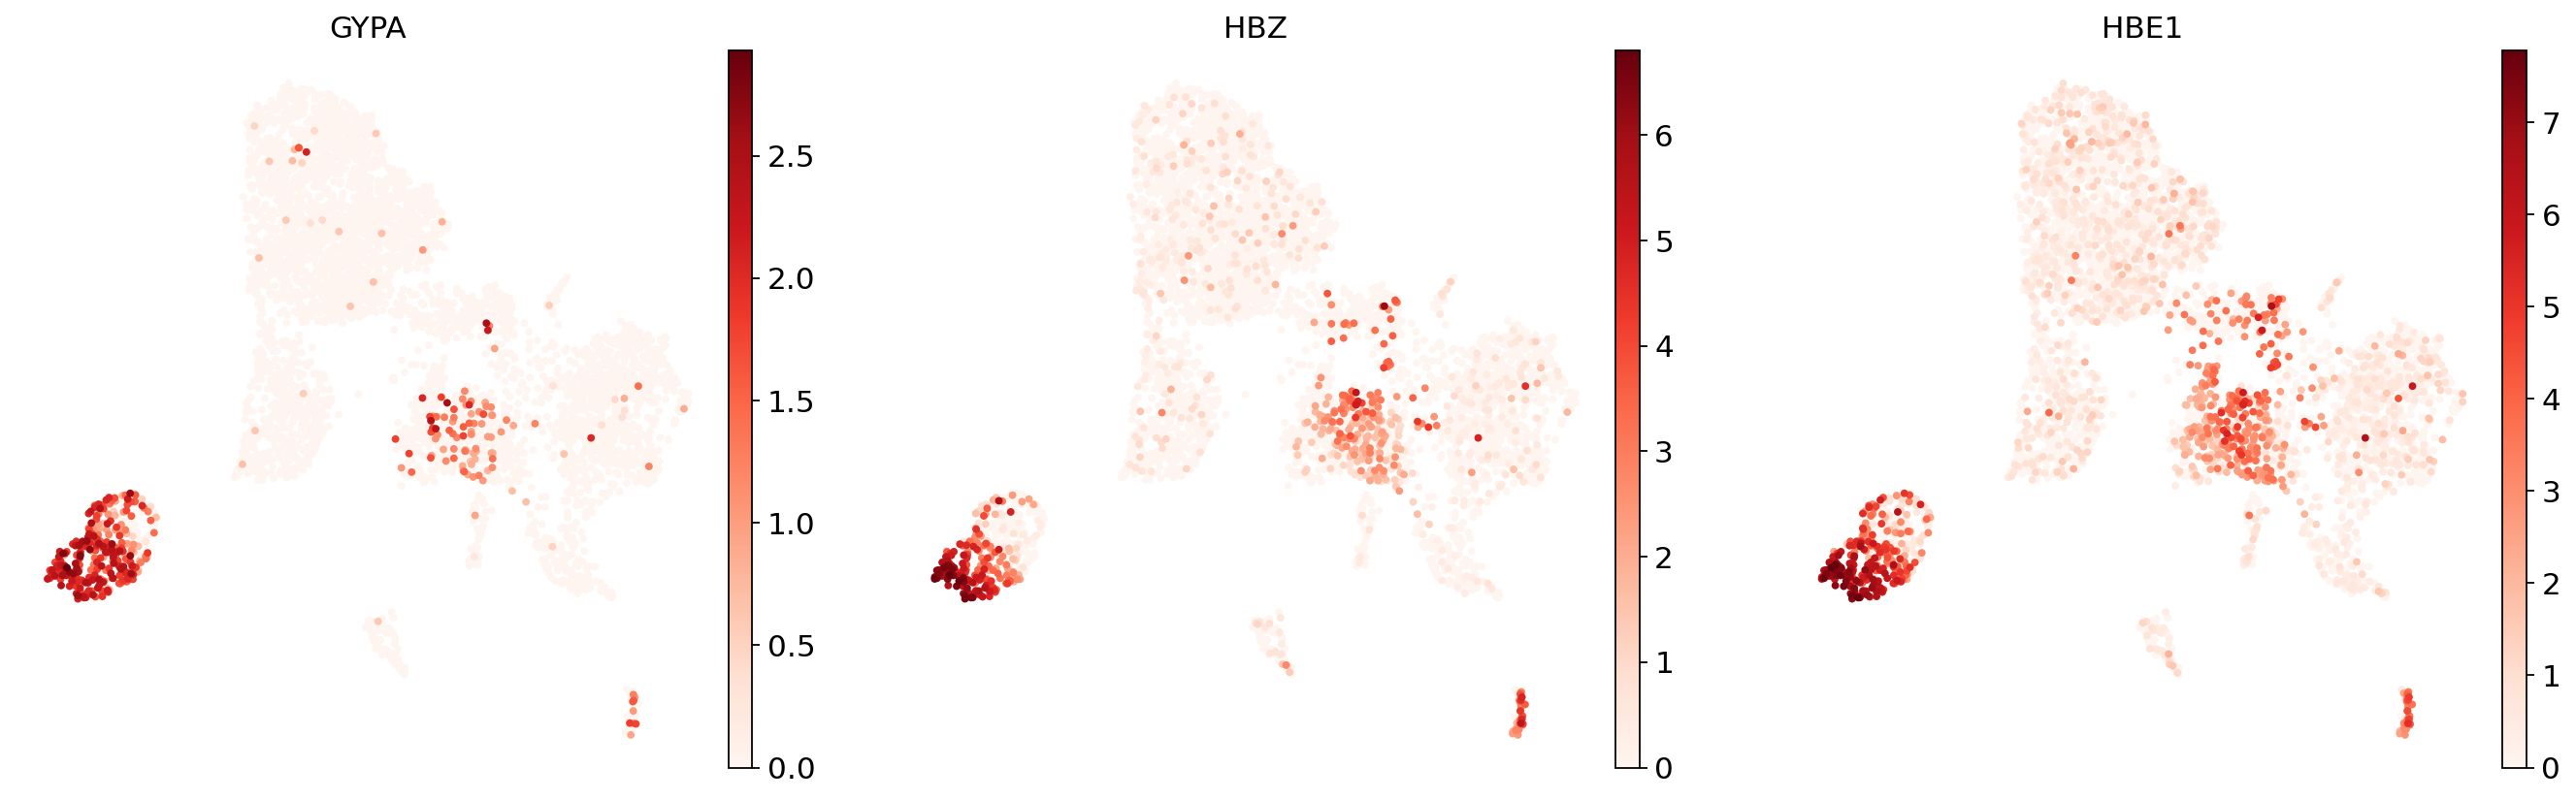

In [7]:
sc.pl.umap(adata, color=['GYPA', 'HBZ', 'HBE1'], frameon=False, size=50)

In [ ]:
sc.pl.umap(adata, color=['leiden_annotation_Tyser_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['Tyser_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden_annotation_Tyser_label_v2'], frameon=False, size=50)
sc.pl.umap(adata, color=['Tyser_label_v2'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden_annotation_hembryo_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['hembryo_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden'], frameon=False, size=50, legend_loc='on data')
sc.pl.umap(adata, color=['leiden'], frameon=False, size=50)

In [ ]:
cluster_annotations = {
    '0': 'Mes',
    '1': 'Amn',
    '2': 'HE1',        
    '3': 'PS',
    '4': 'Amn',    
    '5': 'Adv.Mes',
    '6': 'Adv.Mes',
    '7': 'Epi',       
    '8': 'Blood',   
    '9': 'Adv.Mes',       
    '10': 'Adv.Mes',      
    '11': 'Adv.Mes',
    '12': 'HE2',
    '13': 'PGC',
    '14': 'Endo',
    '15': 'Emerg.Mes'
}

adata.obs['CellType_man'] = adata.obs['leiden'].map(cluster_annotations)
# sc.pl.umap(adata, color=['CellType_man'], show=False)
adata.obs[['Tyser_label', 'Tyser_score', 
        'Tyser_label_v2', 'Tyser_score_v2', 
        'hembryo_label', 'hembryo_score', 
        'leiden_annotation_Tyser_label', 
        'leiden_annotation_Tyser_label_v2',
        'leiden_annotation_hembryo_label',
            'CellType_man'
          ]].to_csv('/mnt/yiming/nfs_share/hema_wave/2512-revision/hemo7_metadata.csv')

adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d7-rna.h5ad')

### Day 12

In [17]:
import celltypist
from celltypist import models
import scipy

hembryo_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/hembryo_model.pkl")

adata = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d12-rna.h5ad')
adata.X = adata.layers['counts']
if scipy.sparse.issparse(adata.X):
    adata.X = adata.X.toarray()
# adata.X[np.isnan(adata.X)] = 0
sc.pp.normalize_total(adata, target_sum = 1e4) 
sc.pp.log1p(adata)

hembryo_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/hembryo_model.pkl")
predictions = celltypist.annotate(adata, model=hembryo_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["hembryo_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["hembryo_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

Tyser_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model.pkl")
predictions = celltypist.annotate(adata, model=Tyser_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

Tyser_model_v2 = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model_v2.pkl")
predictions = celltypist.annotate(adata, model=Tyser_model_v2, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label_v2"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score_v2"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

normalizing counts per cell
    finished (0:00:00)


🔬 Input data has 9010 cells and 29669 genes
🔗 Matching reference genes in the model
🧬 6516 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10


running Leiden clustering
    finished: found 85 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:07)


🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 9010 cells and 29669 genes
🔗 Matching reference genes in the model
🧬 3071 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10


running Leiden clustering
    finished: found 85 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:06)


🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 9010 cells and 29669 genes
🔗 Matching reference genes in the model
🧬 2316 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10


running Leiden clustering
    finished: found 85 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:06)


🗳️ Majority voting the predictions
✅ Majority voting done!


In [18]:
from collections import Counter

# Get Leiden clusters and cell type labels
leiden_clusters = adata.obs['leiden'].astype(str)
cell_types = adata.obs['Tyser_label']

# Create a DataFrame for easier manipulation
df = pd.DataFrame({
    'leiden': leiden_clusters,
    'Tyser_label': cell_types
})

summary_df = pd.crosstab(df['leiden'], df['Tyser_label'], normalize='index') * 100
dominant_types = summary_df.idxmax(axis=1)
dominant_percentages = summary_df.max(axis=1)
dominant_df = pd.DataFrame({
    'Leiden_cluster': dominant_types.index,
    'Dominant_cell_type': dominant_types.values,
    'Percentage': dominant_percentages.values
})
print("\n\nDominant cell types for each Leiden cluster:")
print(dominant_df)

adata.obs['leiden_annotation_v1'] = adata.obs['leiden'].astype(str)  # Start with leiden labels
for leiden_cluster in dominant_types.index:
    mask = adata.obs['leiden'] == leiden_cluster
    adata.obs.loc[mask, 'leiden_annotation_v1'] = dominant_types[leiden_cluster]

print("Annotation mapping:")
for leiden_cluster, cell_type in dominant_types.items():
    print(f"Leiden {leiden_cluster} → {cell_type}")



Dominant cell types for each Leiden cluster:
   Leiden_cluster           Dominant_cell_type  Percentage
0               0                       Amnion   94.938539
1               1            Blood Progenitors   91.493056
2              10  Erythro-Myeloid Progenitors   63.023256
3              11        Hemogenic Endothelium  100.000000
4              12                          PGC   42.105263
5              13  Erythro-Myeloid Progenitors   90.909091
6              14                       Amnion   30.000000
7               2            Advanced Mesoderm   89.075630
8               3            Blood Progenitors  100.000000
9               4            Advanced Mesoderm   74.068966
10              5            Blood Progenitors   85.528031
11              6                Erythroblasts   49.870130
12              7            Advanced Mesoderm   90.095847
13              8                  YS Mesoderm   56.840391
14              9            Blood Progenitors   99.573561
Annotatio

In [19]:
def simple_leiden_annotation(adata, celltype_col):
    """
    Simple function for Leiden annotation.
    """
    import pandas as pd
    
    # Create DataFrame
    df = pd.DataFrame({
        'leiden': adata.obs['leiden'].astype(str),
        'cell_type': adata.obs[celltype_col]
    })
    
    # Calculate dominant types
    summary = pd.crosstab(df['leiden'], df['cell_type'], normalize='index') * 100
    dominant = summary.idxmax(axis=1)
    percentages = summary.max(axis=1)
    
    # Create annotation column
    new_col = f'leiden_annotation_{celltype_col}'
    adata.obs[new_col] = adata.obs['leiden'].astype(str)
    
    for cluster in dominant.index:
        mask = adata.obs['leiden'] == cluster
        adata.obs.loc[mask, new_col] = dominant[cluster]
    
    # Create summary DataFrame
    result_df = pd.DataFrame({
        'Leiden_cluster': dominant.index,
        'Dominant_cell_type': dominant.values,
        'Percentage': percentages.values
    })
    
    return result_df, adata


# Usage
dominant_v1, adata = simple_leiden_annotation(adata, 'Tyser_label')
dominant_v2, adata = simple_leiden_annotation(adata, 'Tyser_label_v2')
dominant_v3, adata = simple_leiden_annotation(adata, 'hembryo_label')

... storing 'leiden_annotation_v1' as categorical
... storing 'leiden_annotation_Tyser_label' as categorical
... storing 'leiden_annotation_Tyser_label_v2' as categorical
... storing 'leiden_annotation_hembryo_label' as categorical


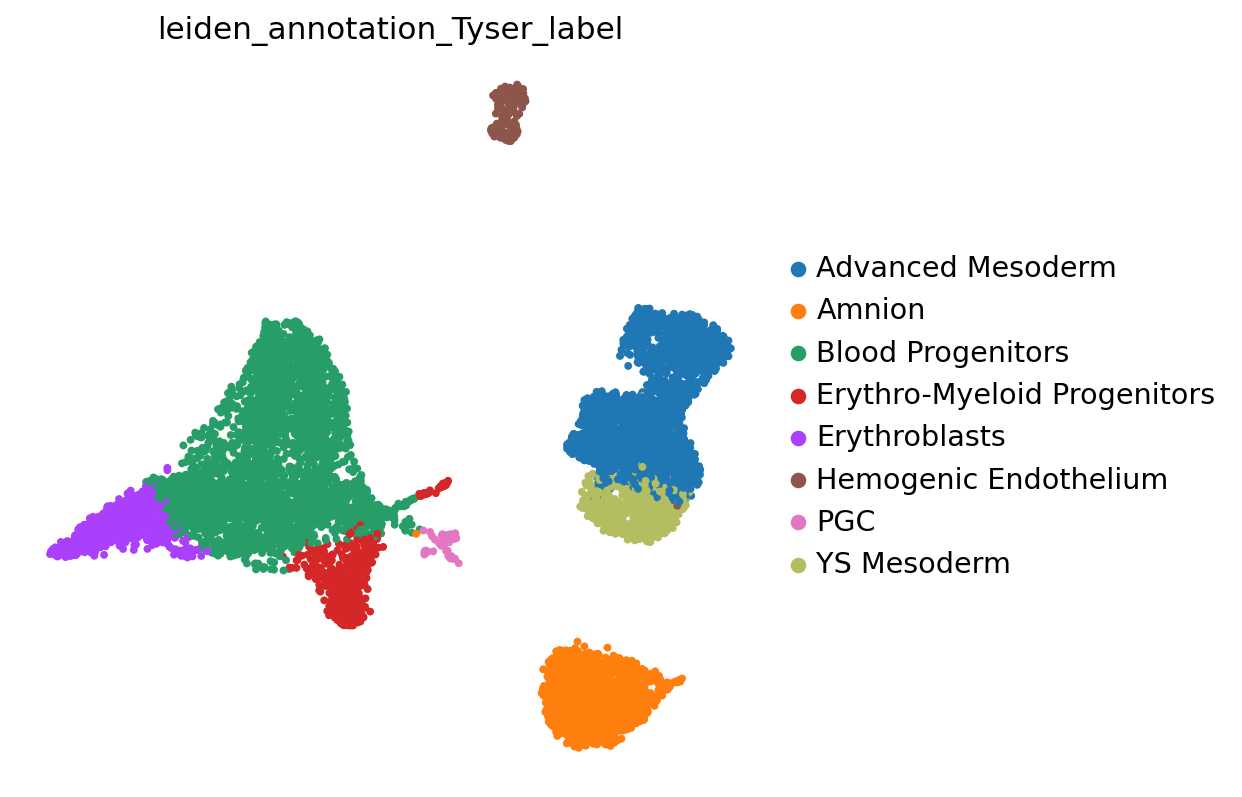

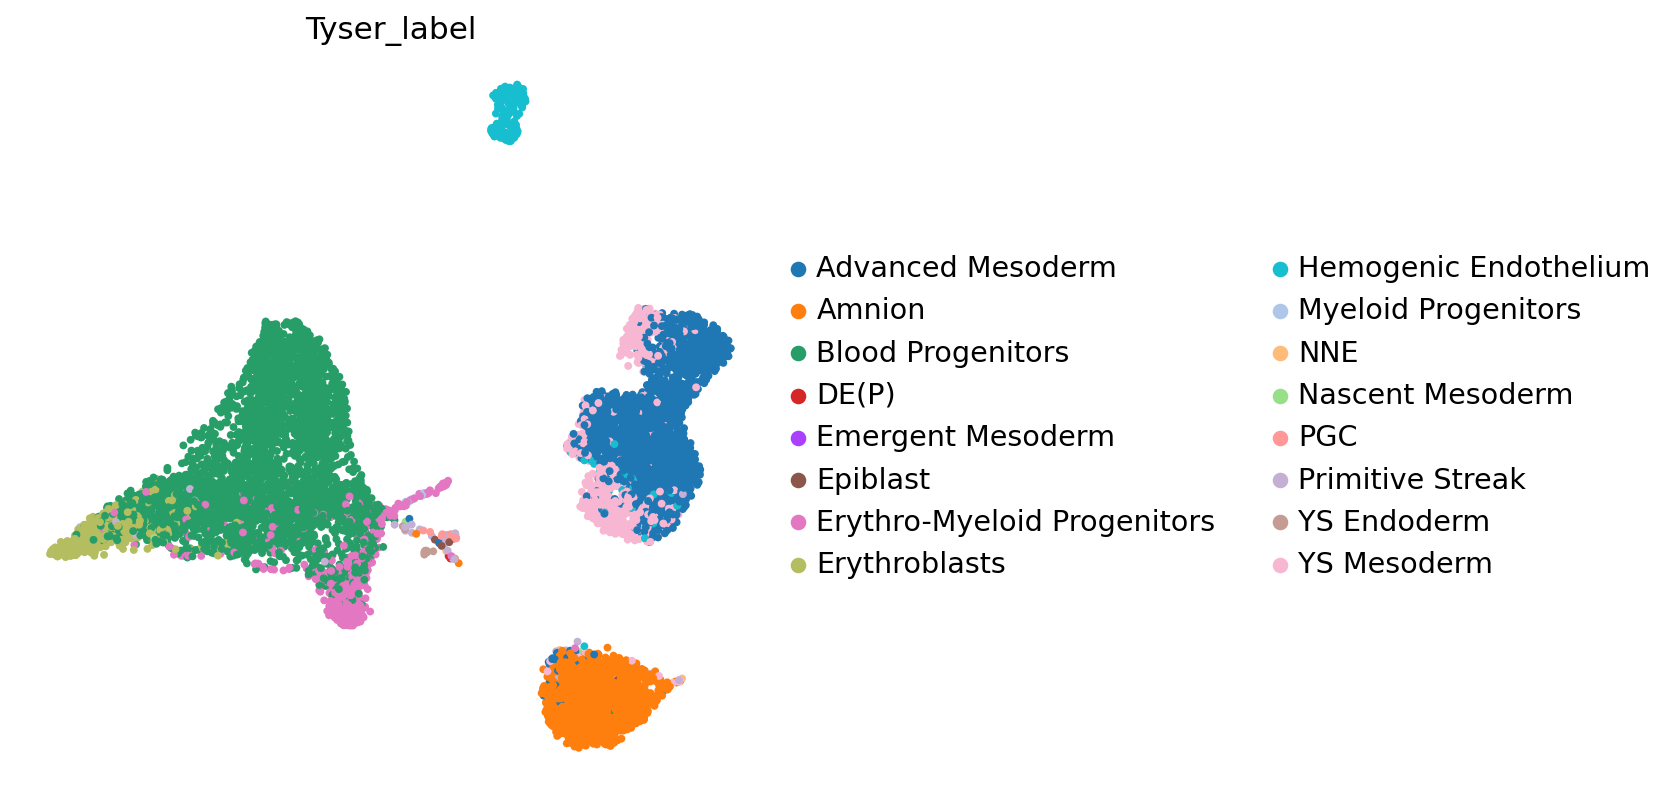

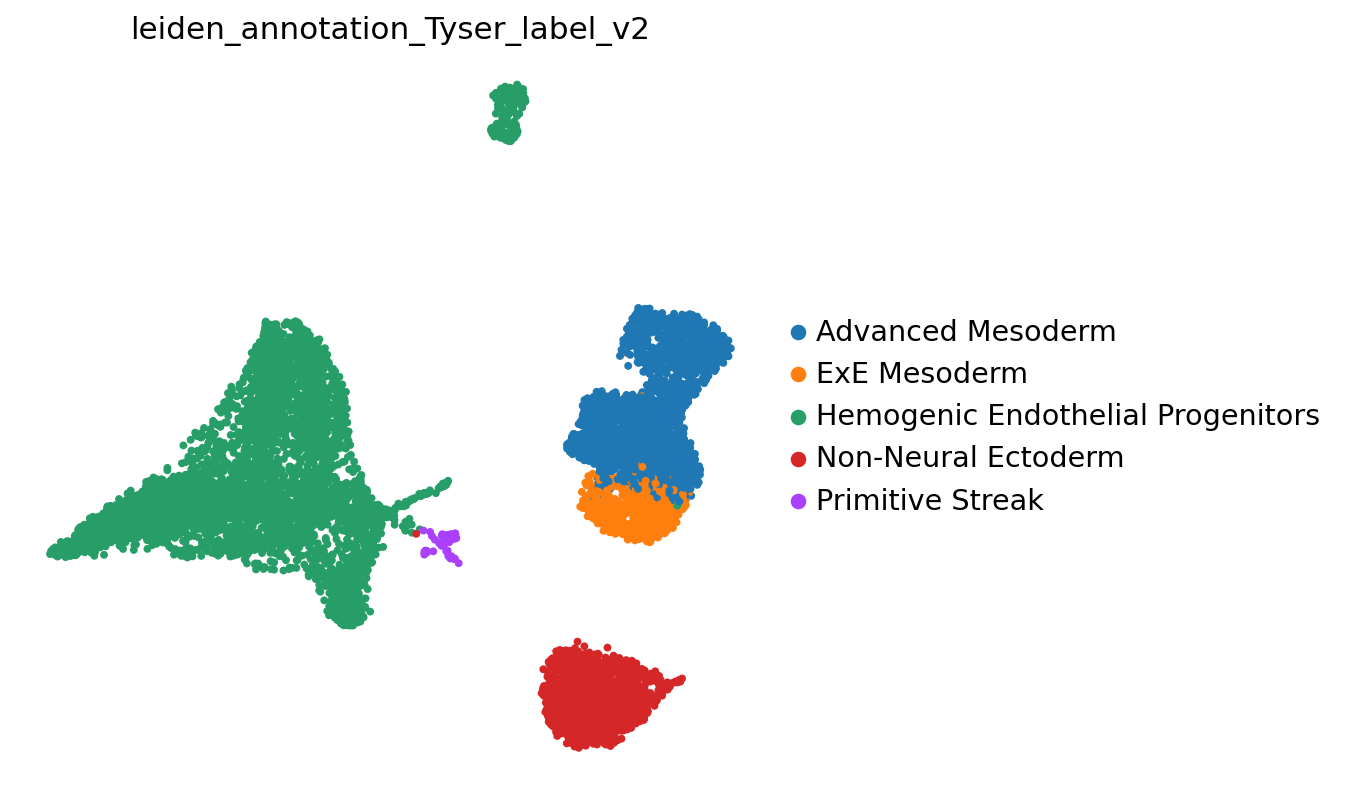

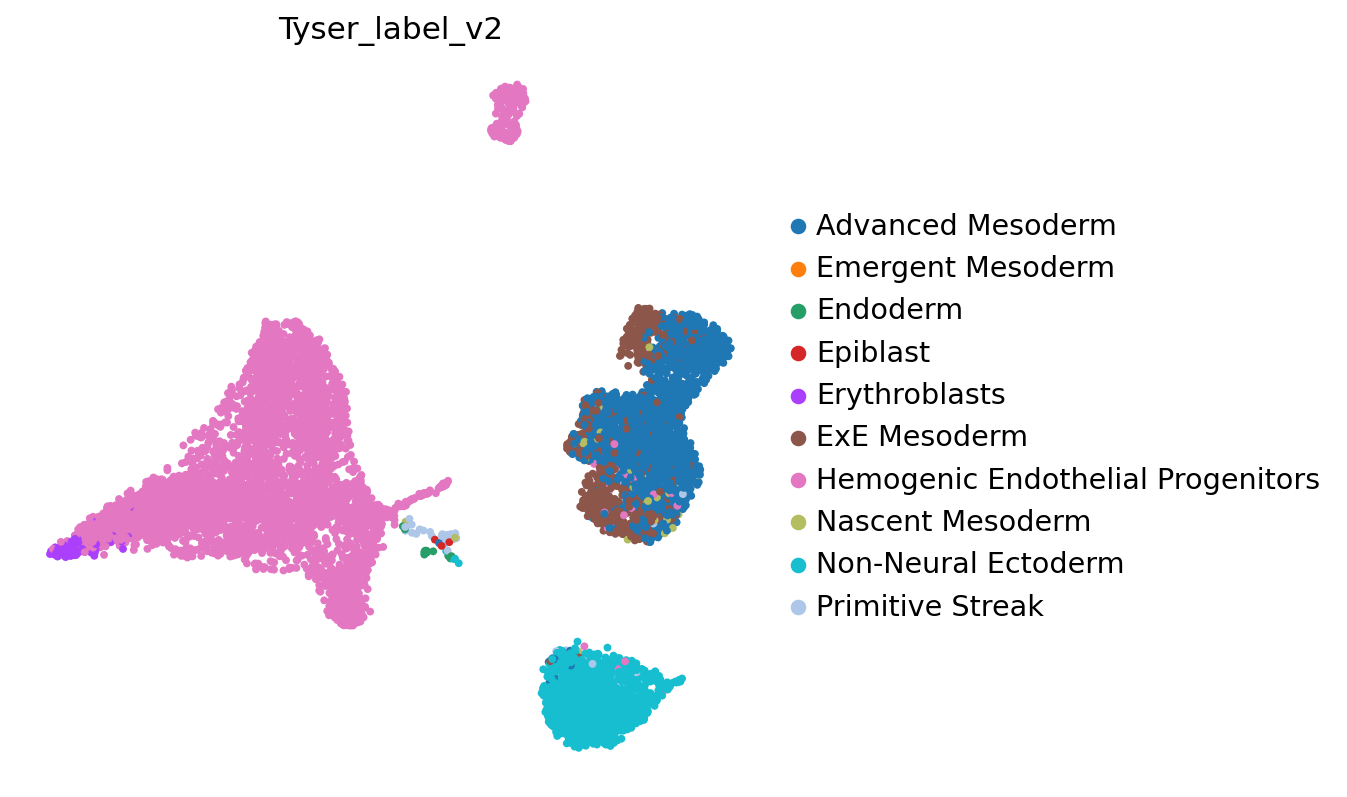

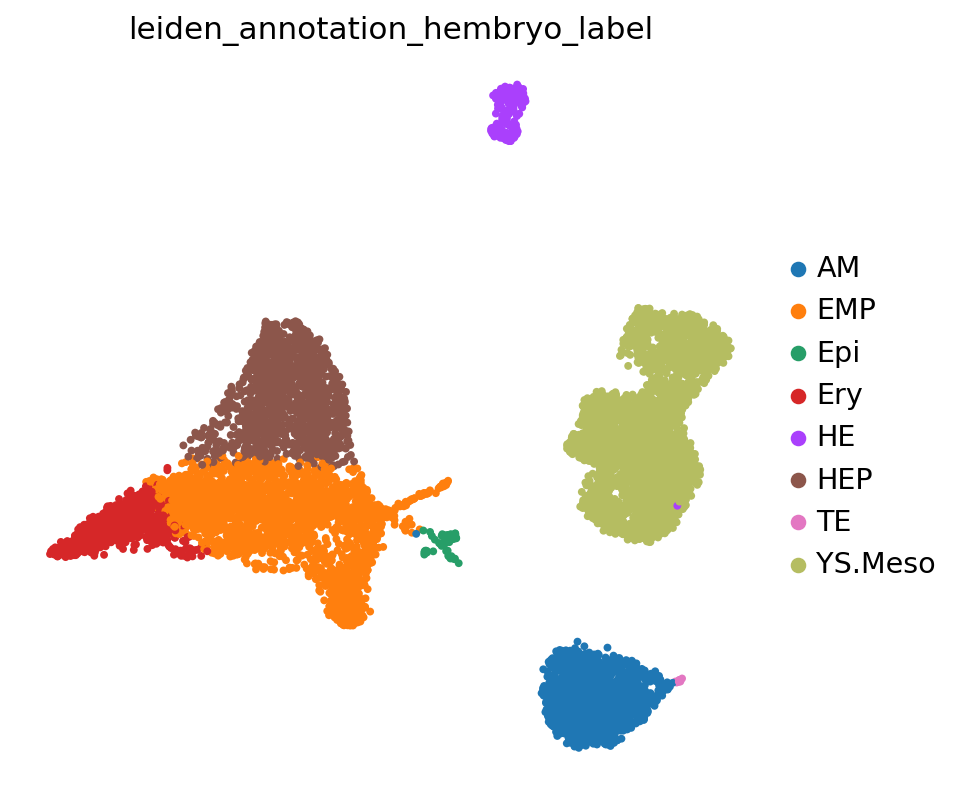

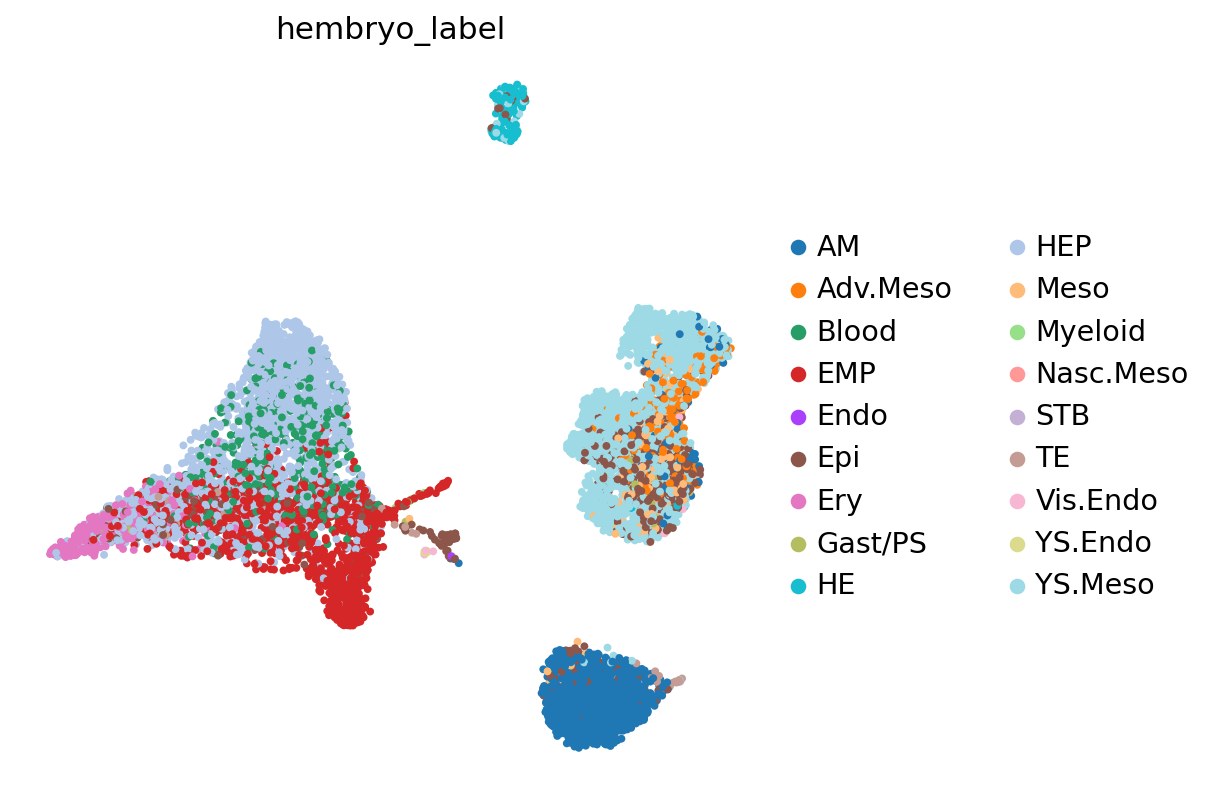

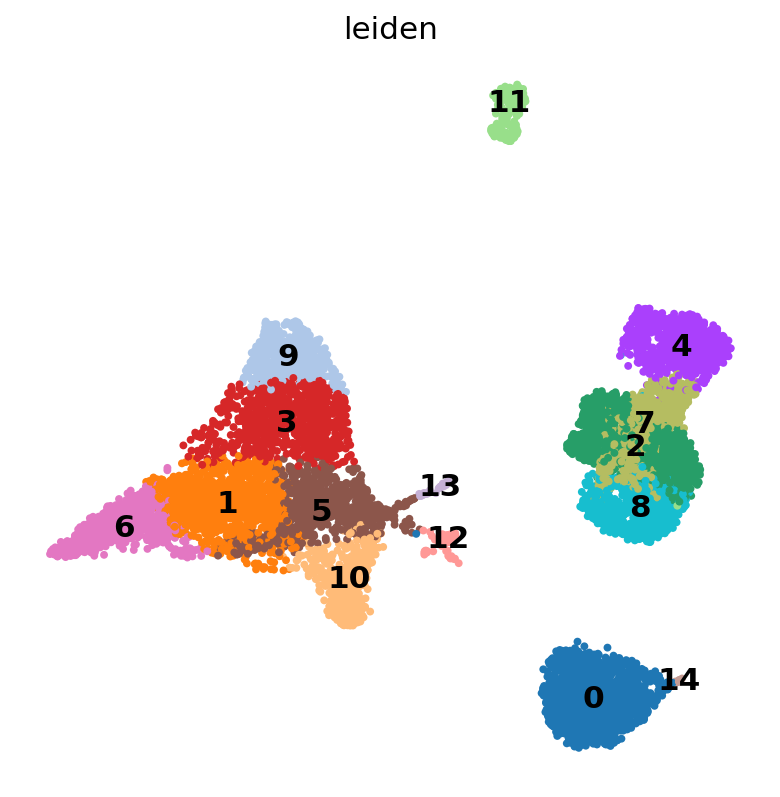

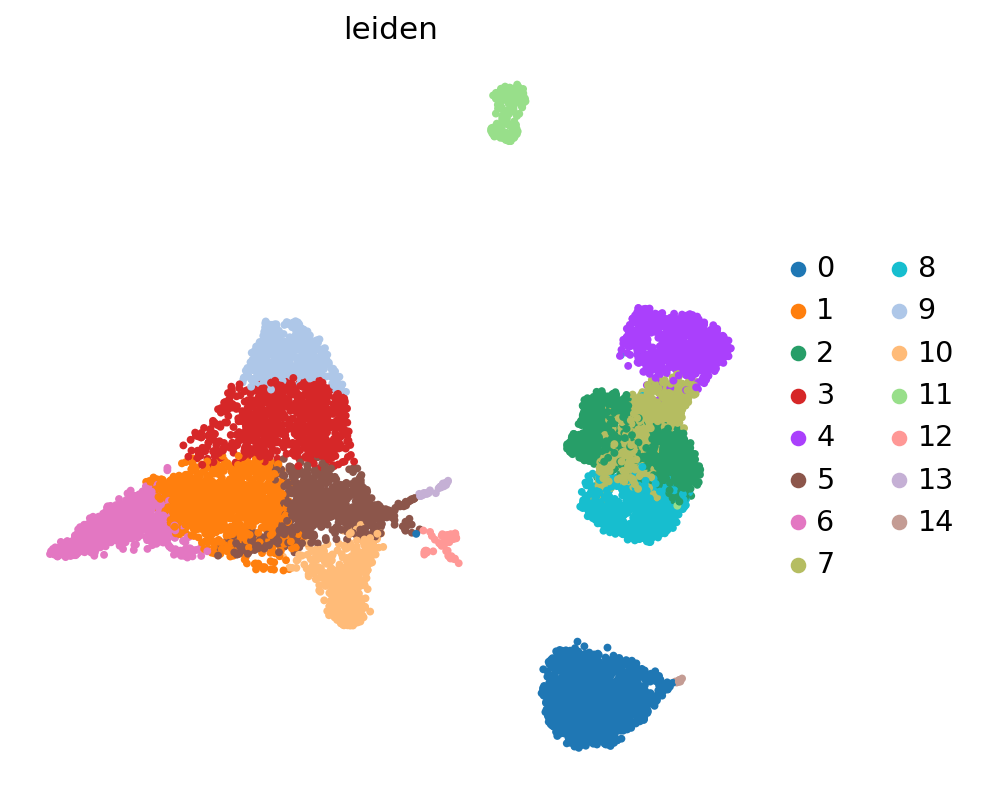

In [20]:
sc.pl.umap(adata, color=['leiden_annotation_Tyser_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['Tyser_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden_annotation_Tyser_label_v2'], frameon=False, size=50)
sc.pl.umap(adata, color=['Tyser_label_v2'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden_annotation_hembryo_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['hembryo_label'], frameon=False, size=50)
sc.pl.umap(adata, color=['leiden'], frameon=False, size=50, legend_loc='on data')
sc.pl.umap(adata, color=['leiden'], frameon=False, size=50)

In [9]:
adata_sub = adata[adata.obs['leiden']=='11']
sc.tl.pca(adata_sub, svd_solver='arpack')
sc.pp.neighbors(adata_sub, n_pcs=30, n_neighbors=10)
sc.tl.leiden(adata_sub, resolution=0.3) 

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
running Leiden clustering
    finished: found 2 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [ ]:
arterial_markers = [
    'DLL4',      # Delta-like 4 - Key arterial specification gene
    'HEY1',      # Hairy/enhancer-of-split related with YRPW motif
    'HEY2',      # 
    'EFNB2',     # Ephrin B2 - Classic arterial marker
    'CXCR4',     # Chemokine receptor
    'GJA5',      # Connexin 40 (Cx40)
    'GJA4',      # Connexin 37 (Cx37)
    'SOX17',     # Transcription factor
    'FBLN5',     # Fibulin-5
    'NOTCH1',    # Notch receptor 1
    'NOTCH4',    # Notch receptor 4
    'JAG1',      # Jagged 1 (Notch ligand)
    'BMX',       # Bone marrow tyrosine kinase
    'ARHGEF15',  # Rho guanine exchange factor
    'PODXL',     # Podocalyxin-like
    'TIE1',      # Tyrosine kinase with Ig-like and EGF-like domains 1
    'EGFL7',     # Epidermal growth factor-like domain 7
    'CDH5',      # VE-cadherin (endothelial, but arterial-enriched)
]
venous_markers = [
    'NR2F2',     # COUP-TFII - Master venous regulator
    'EPHB4',     # Ephrin receptor B4 - Classic venous marker
    'APLNR',     # Apelin receptor
    'ACKR1',     # Atypical chemokine receptor 1 (DARC)
    'NPPB',      # Natriuretic peptide B
    'VWF',       # von Willebrand factor (higher in veins)
    'VCAM1',     # Vascular cell adhesion molecule 1
    'ICAM1',     # Intercellular adhesion molecule 1
    'SELE',      # E-selectin
    'SELP',      # P-selectin
    'CD36',      # Fatty acid translocase
    'LYVE1',     # Lymphatic vessel endothelial hyaluronan receptor 1
    'MSR1',      # Macrophage scavenger receptor 1
    'CXCR7',     # Atypical chemokine receptor 3
    'PLVAP',     # Plasmalemma vesicle-associated protein
    'PROX1',     # Prospero homeobox 1 (also lymphatic)
    'FLT4',      # VEGFR3 (also lymphatic)
    'CCL21',     # Chemokine ligand 21 (also lymphatic)
]
# Create a combined list for visualization
arteriovenous_markers = arterial_markers + venous_markers

# Filter to genes actually present in your dataset
available_markers = [gene for gene in arteriovenous_markers 
                     if gene in adata.var_names]

# Dot plot or violin plot
sc.pl.dotplot(adata_sub, 
              var_names=available_markers[:20],  # First 20 available
              groupby='leiden',
              dendrogram=True,
              swap_axes=True)

# Heatmap
sc.pl.heatmap(adata_sub,
              var_names=available_markers[:30],
              groupby='leiden',
              dendrogram=True)

# Feature plots on UMAP
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

top_markers = ['DLL4', 'EFNB2', 'HEY1', 'NR2F2', 'EPHB4', 'ACKR1']
for i, gene in enumerate(top_markers):
    if gene in adata.var_names:
        sc.pl.umap(adata_sub, color=gene, ax=axes[i], show=False, 
                   frameon=False, title=gene)
plt.tight_layout()
plt.show()

In [ ]:
cluster_annotations = {
    '0': 'Amn',
    '1': 'MkP',
    '2': 'Adv.Mes',        
    '3': 'Mk',
    '4': 'Adv.Mes',    
    '5': 'MkP',
    '6': 'MkP',
    '7': 'Adv.Mes',       
    '8': 'YS.Mes',   
    '9': 'Mk',       
    '10': 'EMP',      
    '11': 'HE',
    '12': 'PGC',
    '13': 'Gran',
    '14': 'Amn'
}
adata.obs['CellType_man'] = adata.obs['leiden'].map(cluster_annotations)

if 'leiden' in adata_sub.obs.columns:
    # Get indices of cells in cluster 0 (Vein) and cluster 1 (Art)
    vein_cells = adata_sub.obs_names[adata_sub.obs['leiden'] == '0']
    art_cells = adata_sub.obs_names[adata_sub.obs['leiden'] == '1']
    adata.obs.loc[vein_cells, 'CellType_man'] = 'Vein'
    adata.obs.loc[art_cells, 'CellType_man'] = 'Art'
    
sc.pl.umap(adata, color=['CellType_man'], show=False)
adata.obs[['Tyser_label', 'Tyser_score', 
        'Tyser_label_v2', 'Tyser_score_v2', 
        'hembryo_label', 'hembryo_score', 
        'leiden_annotation_Tyser_label', 
        'leiden_annotation_Tyser_label_v2',
        'leiden_annotation_hembryo_label',
            'CellType_man'
          ]].to_csv('/mnt/yiming/nfs_share/hema_wave/2512-revision/hemo12_metadata.csv')

adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d12-rna.h5ad')

In [11]:
sc.pl.umap(adata, color=['CellType_man'], frameon=False, legend_loc='on data', 
           legend_fontsize=10, legend_fontoutline=2, title='Cell Type', 
           size=50, show=False)
plt.savefig(f'/mnt/yiming/nfs_share/hema_wave/2512-revision/umap_hemo12_CellType_man_legendon.svg', 
                format='svg', dpi=300, bbox_inches='tight')
plt.close()